In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
x = df[['Annual Income (k$)', 'Spending Score (1-100)']]
# we usually use only Annual Income Spending Score, because the clusters can be visualized in 2D.

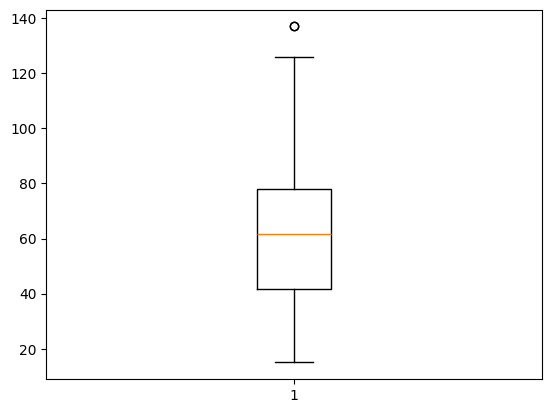

In [6]:
plt.boxplot(df['Annual Income (k$)'])
plt.show()

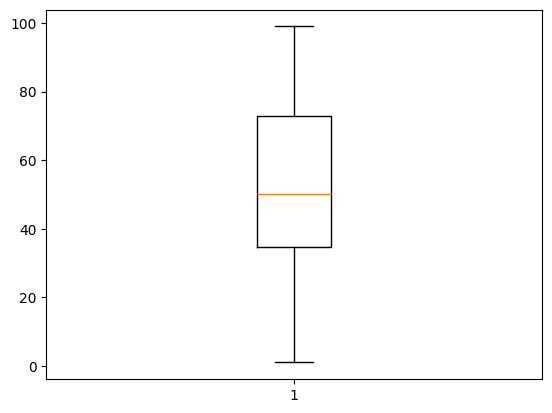

In [7]:
plt.boxplot(df['Spending Score (1-100)'])
plt.show()

### Our dataset has lass outlayers then we have to use StandardScaler, here only one outlayer

In [ ]:
main_pipeline = Pipeline(
    steps=[
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=5, random_state=42))
])

In [9]:
main_pipeline.fit(x)

,steps,"[('scaler', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300


In [ ]:
main_pipeline.fit_predict(x) # returns cluster values
# by using fit_transform() -> we get the distance from the centroids

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [11]:
labels = main_pipeline.named_steps['kmeans'].labels_

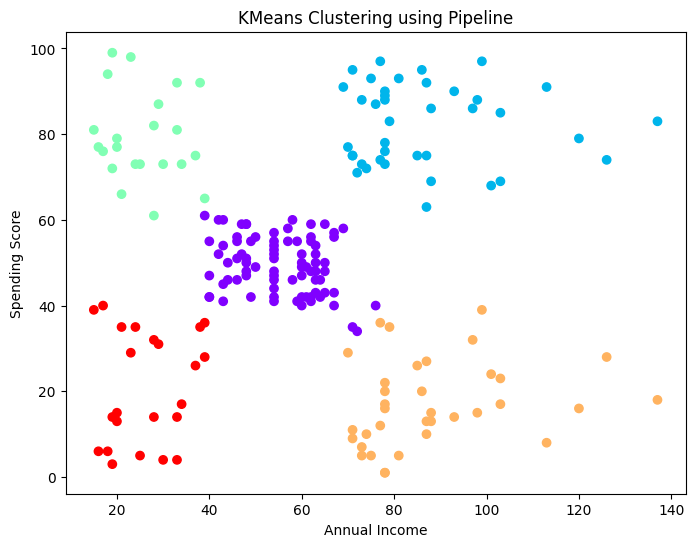

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    x['Annual Income (k$)'],
    x['Spending Score (1-100)'],
    c=labels,
    cmap='rainbow'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("KMeans Clustering using Pipeline")
plt.show()

In [13]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [14]:
# Choose different columns
x = df[['Age', 'Annual Income (k$)']]

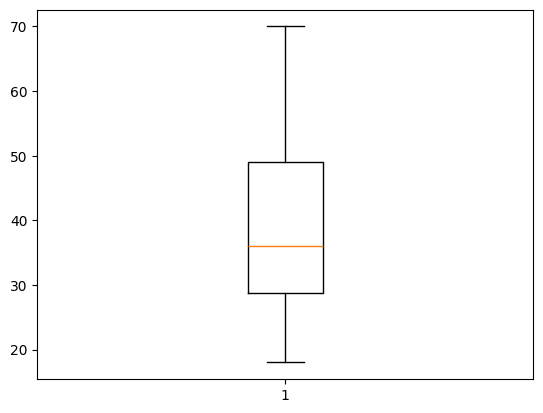

In [15]:
plt.boxplot(df['Age'])
plt.show()

### Our dataset has lass outlayers then we have to use StandardScaler

In [16]:
main_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=5, random_state=42))
])

In [17]:
main_pipeline.fit_predict(x)

array([2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       0, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       4, 0, 2, 2, 0, 4, 0, 0, 0, 1, 4, 4, 1, 4, 0, 4, 0, 4, 1, 4, 0, 1,
       1, 4, 0, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 0, 1, 4, 1, 0, 4, 0, 0,
       0, 1, 4, 1, 1, 1, 0, 4, 4, 4, 1, 4, 4, 4, 1, 1, 4, 4, 4, 4, 4, 4,
       1, 1, 1, 1, 4, 1, 1, 1, 4, 1, 1, 1, 1, 1, 4, 1, 1, 1, 4, 4, 4, 4,
       4, 1, 1, 1, 1, 1, 4, 1, 1, 1, 4, 1, 4, 1, 1, 1, 4, 1, 1, 1, 4, 1,
       4, 1, 4, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3], dtype=int32)

In [18]:
labels = main_pipeline.named_steps['kmeans'].labels_

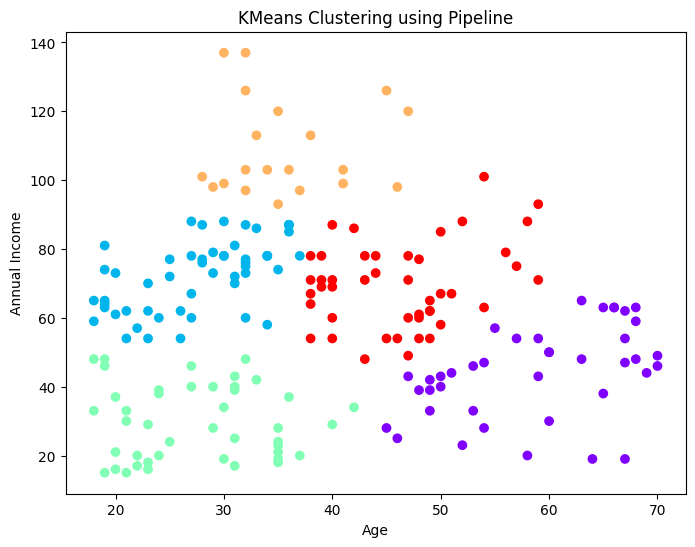

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    x['Age'],
    x['Annual Income (k$)'],
    c=labels,
    cmap='rainbow'
)

plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.title("KMeans Clustering using Pipeline")
plt.show()

In [ ]:
preprocessing = ColumnTransfomer{
    transformer = [
        ('std', 'S')
    ]
}

# Elbow Method

In [ ]:
metrics_ = []
for cluster in range(1, 10):
    main_pipeline = Pipeline(
        steps=[
            ('pre', preprocessing),
            ('model', KMeans(n_clusters=cluster, random_state=42)) # default it takes 8
        ]
    )
    main_pipeline.fit(x)
    metric = main_pipeline.named_steps['model'].interia_
    metrics_.append(metric)
print(metrics_)